# Project- 1

Implementation of VO using simplified methods from project.ipynb

## Import Modules

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math
import scipy.signal
import scipy.linalg
import scipy.spatial.distance
import mae6292.tools as mae6292
import importlib

from mae6292.imshow import cv2_imshow
from mae6292.tools import (
    VO_bootstrap, VO_localization_mapping,
    state, candidate
)

In [13]:
%matplotlib inline

# load K and first two images
K = np.loadtxt('data/K.txt')
img0 = cv2.imread('data/img_00000.png', cv2.IMREAD_GRAYSCALE)

print('K=',K)
cv2_imshow(img0)

K= [[331.37    0.    320.   ]
 [  0.    369.568 240.   ]
 [  0.      0.      1.   ]]


## Bootstrapping

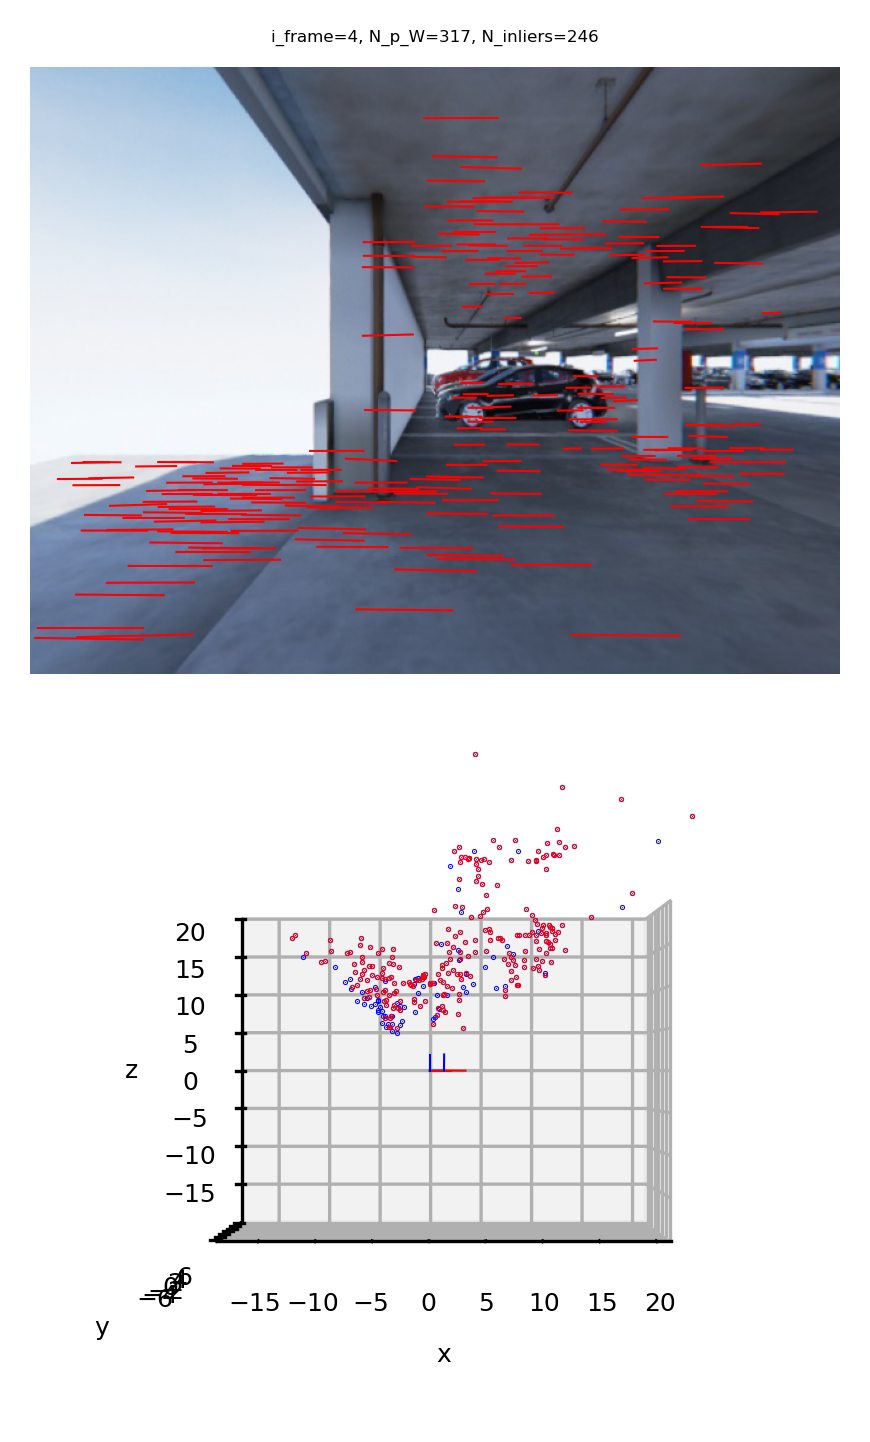

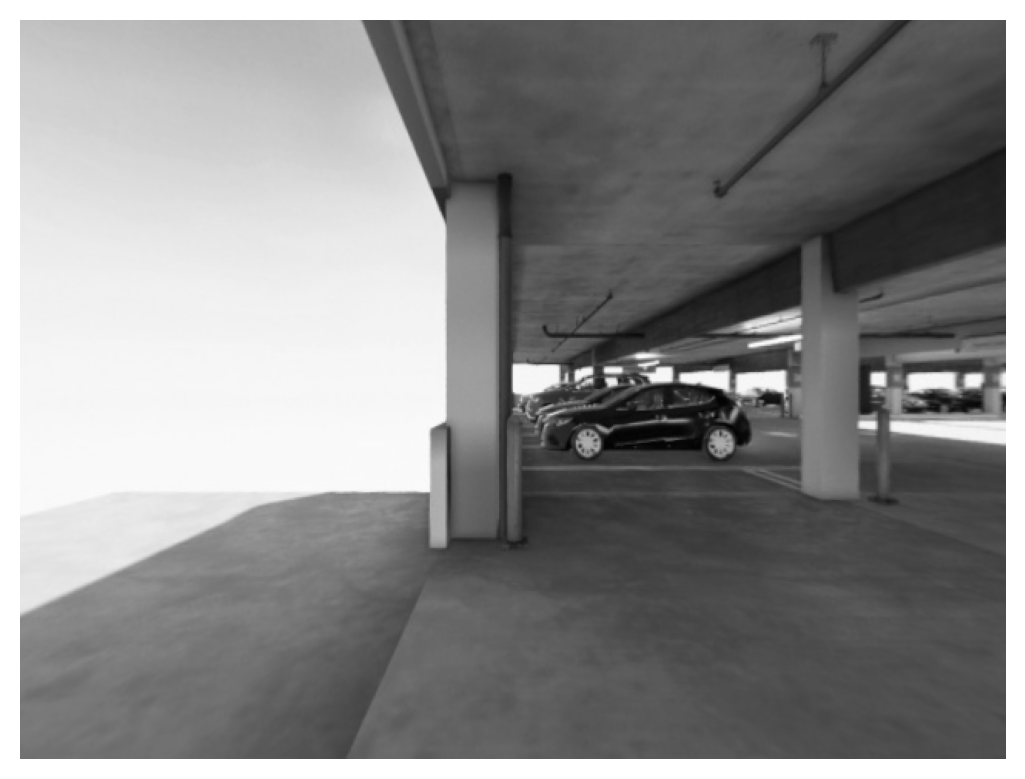

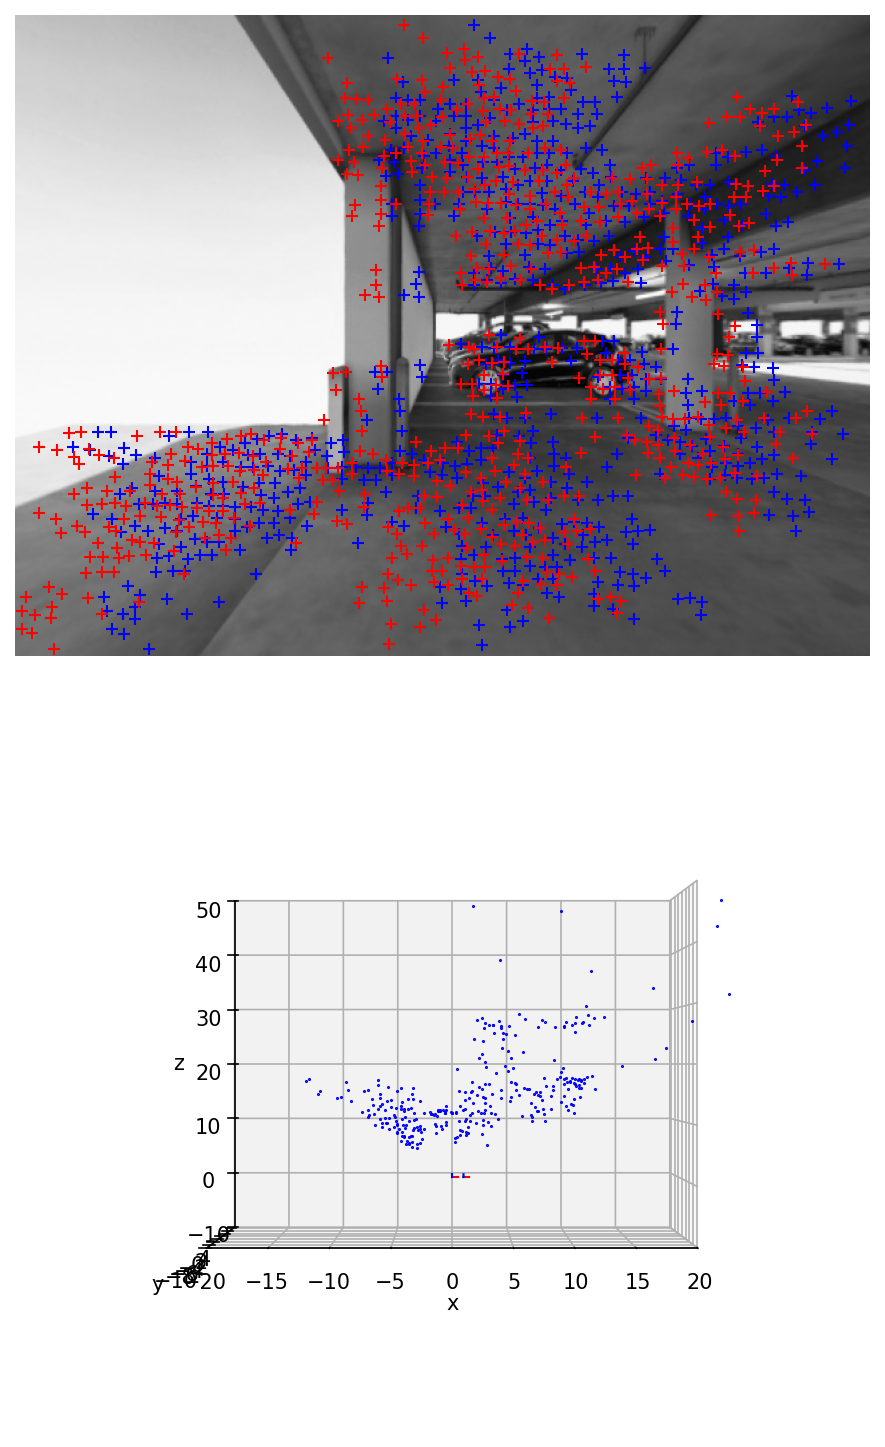

N_keypoints0= 317


In [ ]:
# PARAMETERS 
param = {
    # keypoints
    'W_harris_patch' : 4, # size of harris patch
    'kappa_harris' : 0.08, # kappa for harris score
    'N_keypoint' : 2000, # number of keypoints to be detected
    'W_nms' : 8, # patch size for non-maximum supression
    # KLT
    'W_KLT' : 4, # patch size for KLT
    'tol_KLT_bidir' : 1, # tolerence of bidirectional error
    # find essential matrix
    'tol_E' : 1, # tolerence for epipolar line distance
    'tol_E_RANSAC_prob' : 0.99, # essential matrix RANSAC probability
    # triangulation
    'tol_TRI_mu' : 1e-3, # tolerence for the singular value ratio
    'tol_TRI_rep' : 1, # tolerence for the reprojection error
    # mapping
    'tol_keypoints_new' : 18 # new keypoints should be district from the tracked keypoints by this distance
}

# Load bootstrap images
BOOT_IDX = 3
img1 = cv2.imread('data/img_{:05d}.png'.format(BOOT_IDX), cv2.IMREAD_GRAYSCALE)

# Bootstrap
keypoints0, p_W0, R1, T1 = mae6292.VO_bootstrap(img0, img1, K, param, display=True)
plt.savefig('prob1_bootstrap.png')
plt.show()

print('N_keypoints0=',len(keypoints0))

## Localization and Mapping 

In [22]:
%matplotlib inline
importlib.reload(mae6292)

import os

# Create output directory for frames
os.makedirs('prob1_frames', exist_ok=True)

# Initialize iteration using img0
img_pre = img0
S_pre = mae6292.state(keypoints0, p_W0, [np.zeros((3,1))])
C_pre = mae6292.candidate([],[],[],[])

# number of frames to process
N_frames = 200
display_process = True  # set to True to save frame visualizations (slower)

# variables to save the vehicle location and the keypoints in the W-frame 
T_W = np.zeros((3,N_frames+1))
p_W = p_W0.copy()

for i_frame in range(BOOT_IDX+1, N_frames+1):
    
    if i_frame % 20 == 0:
        print('i_frame=', i_frame)

    # VO localization and mapping
    img = cv2.imread('data/img_{:05d}.png'.format(i_frame), cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f'Frame {i_frame} not found. Stopping.')
        N_frames = i_frame - 1
        break
        
    img_rgb = cv2.cvtColor(cv2.imread('data/img_{:05d}.png'.format(i_frame)), cv2.COLOR_BGR2RGB)
    R, T, S, C, fig = mae6292.VO_localization_mapping(i_frame, img, img_rgb, img_pre, S_pre, C_pre, K, param, display_process)
    img_pre, S_pre, C_pre = img, S, C

    # save figure if visualization is enabled
    if display_process and fig is not None:
        fig.savefig('prob1_frames/{:06d}.png'.format(i_frame))
        plt.close(fig)

    # save the vehicle location and the distinct keypoints 
    T_W[:,i_frame] = (-R.T@T).flatten()
    p_W_dist = scipy.spatial.distance.cdist(S.p_W.T, p_W.T, 'euclidean')
    index_distinct = np.where(np.min(p_W_dist, axis=1) > 3)[0]
    p_W = np.append(p_W, S.p_W[:,index_distinct], axis=1)

print(f'Processed {N_frames} frames')

S_pre= 246 , KLT_matched= 236 , PnP_inliers= 235 , S_new =  571
C_pre= 1342 , KLT_matched= 653 , TRI_inliers= 336 , C_new =  660
S_pre= 571 , KLT_matched= 526 , PnP_inliers= 524 , S_new =  566
C_pre= 660 , KLT_matched= 280 , TRI_inliers= 42 , C_new =  580
S_pre= 566 , KLT_matched= 532 , PnP_inliers= 530 , S_new =  558
C_pre= 580 , KLT_matched= 242 , TRI_inliers= 28 , C_new =  569
S_pre= 558 , KLT_matched= 517 , PnP_inliers= 513 , S_new =  535
C_pre= 569 , KLT_matched= 207 , TRI_inliers= 22 , C_new =  548
S_pre= 535 , KLT_matched= 499 , PnP_inliers= 491 , S_new =  517
C_pre= 548 , KLT_matched= 208 , TRI_inliers= 26 , C_new =  543
S_pre= 517 , KLT_matched= 487 , PnP_inliers= 478 , S_new =  502
C_pre= 543 , KLT_matched= 195 , TRI_inliers= 24 , C_new =  570
S_pre= 502 , KLT_matched= 472 , PnP_inliers= 435 , S_new =  465
C_pre= 570 , KLT_matched= 196 , TRI_inliers= 30 , C_new =  580
S_pre= 465 , KLT_matched= 436 , PnP_inliers= 432 , S_new =  482
C_pre= 580 , KLT_matched= 211 , TRI_inliers= 

## Generate Trajectory Map 

Simple 3D visualization of trajectory and landmarks

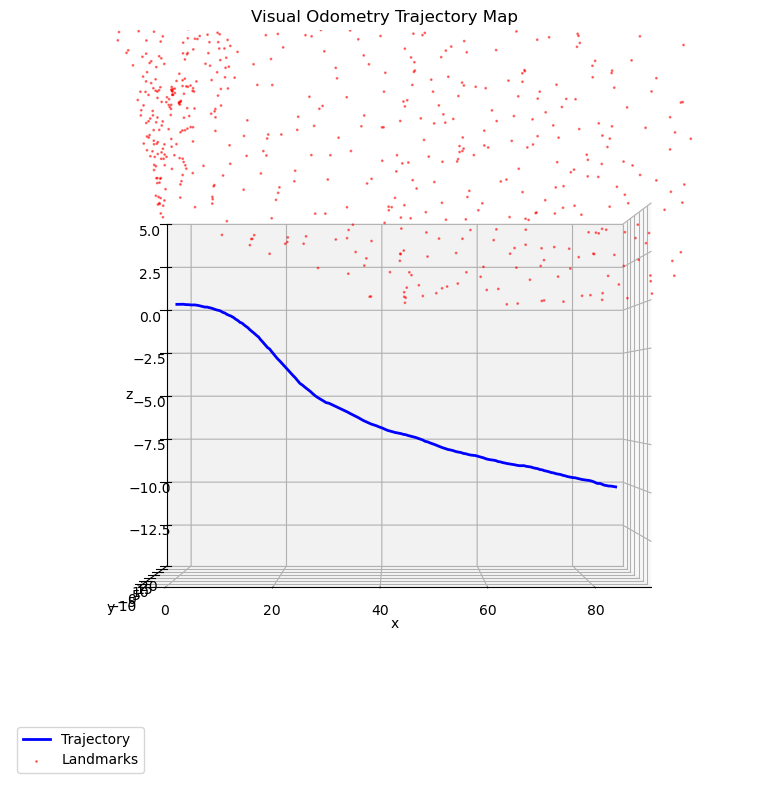

Saved prob1_map.png


In [23]:
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')
ax.plot(T_W[0,:N_frames+1], T_W[1,:N_frames+1], T_W[2,:N_frames+1], 'b', linewidth=2, label='Trajectory')
ax.scatter(p_W[0,:], p_W[1,:], p_W[2,:], s=1, c='r', marker='o', alpha=0.5, label='Landmarks')
ax.set_xlim(T_W[0,:N_frames+1].min()-5, T_W[0,:N_frames+1].max()+5)
ax.set_zlim(T_W[2,:N_frames+1].min()-5, T_W[2,:N_frames+1].max()+5)
ax.set_xlabel('x', fontsize=10)
ax.set_ylabel('y', fontsize=10)
ax.set_zlabel('z', fontsize=10)
ax.set_title('Visual Odometry Trajectory Map', fontsize=12)
ax.legend()
ax.view_init(elev=0., azim=-90)

plt.tight_layout()
plt.savefig('prob1_map.png', dpi=150)
plt.show()

print('Saved prob1_map.png')

## Generate Video 

Create MP4 from saved frame images. **Note:** requires `display_process=True` in the localization loop to save frames.

In [ ]:
# Read saved frames and create MP4 video
img_array = []
for i_frame in range(BOOT_IDX+1, N_frames+1):
    filename = 'prob1_frames/{:06d}.png'.format(i_frame)
    img = cv2.imread(filename)
    if img is not None:
        img_array.append(img)

if len(img_array) > 0:
    height, width, layers = img_array[0].shape
    size = (width, height)
    fps = 10
    codec = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter('prob1.mp4', codec, fps, size)
    
    for i in range(len(img_array)):
        out.write(img_array[i])
    
    out.release()
    print(f'Saved prob1.mp4 with {len(img_array)} frames')
else:
    print('No frames found. To generate video:')
    print('1. Set display_process=True in the localization loop')
    print('2. Re-run the localization and mapping cell')
    print('3. Then run this cell to create the video')

Saved prob1.mp4 with 197 frames
